# Análisis de caso Lección 5-Técnicas de reducción dimensional

El análisis se realizó utilizando el Parkinson’s Disease Dataset, disponible en el repositorio UCI Machine Learning Repository. Este conjunto de datos contiene 195 registros correspondientes a grabaciones de voz de pacientes, a partir de las cuales se extrajeron 22 variables biométricas relacionadas con características acústicas como frecuencia fundamental, variaciones de tono y medidas de perturbación vocal.

Cada registro incluye además una variable denominada status, que indica el diagnóstico del paciente, donde 1 representa presencia de enfermedad de Parkinson y 0 indica un individuo saludable. Estas mediciones permiten analizar patrones en las características vocales que podrían estar asociadas con la presencia de la enfermedad, facilitando el estudio de técnicas de análisis y reducción dimensional en datos biomédicos.

In [42]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

Cargo dataset

In [43]:
df = pd.read_csv("parkinsons.data")

df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


Exploro características del dataset

In [44]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 17  status  

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [45]:
df.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

No existen valores nulos

In [46]:
#Saco name porque no la utilizaré para el modelo

X = df.drop(["name","status"], axis=1) # variables biomédicas
y = df["status"] # diagnóstico Parkinson

Aplicación de StandardScaler 

In [47]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**3.	Aplicación de PCA:**

Determinar número óptimo de componentes

In [48]:
pca_full = PCA()

pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

# Mostrar resultados
resultados = pd.DataFrame({
    "Componente": [f"PC{i}" for i in range(1, len(var_exp) + 1)],
    "Varianza_Explicada": var_exp,
    "Varianza_Acumulada": var_acum
})

print(resultados)


   Componente  Varianza_Explicada  Varianza_Acumulada
0         PC1        5.890050e-01            0.589005
1         PC2        1.129943e-01            0.701999
2         PC3        7.009226e-02            0.772092
3         PC4        6.659028e-02            0.838682
4         PC5        4.426891e-02            0.882951
5         PC6        3.314129e-02            0.916092
6         PC7        2.510204e-02            0.941194
7         PC8        1.647288e-02            0.957667
8         PC9        1.317446e-02            0.970841
9        PC10        1.018756e-02            0.981029
10       PC11        6.389325e-03            0.987418
11       PC12        4.765515e-03            0.992184
12       PC13        3.169860e-03            0.995354
13       PC14        1.734831e-03            0.997089
14       PC15        1.000531e-03            0.998089
15       PC16        8.085245e-04            0.998898
16       PC17        5.661999e-04            0.999464
17       PC18        3.27915

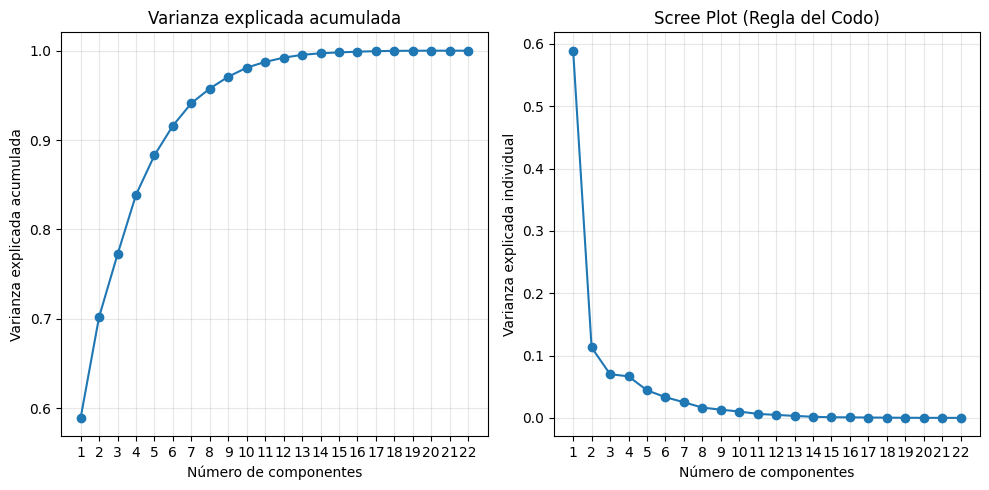

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# 1. Varianza acumulada
axes[0].plot(range(1, len(var_acum) + 1), var_acum, marker="o")
axes[0].set_xlabel("Número de componentes")
axes[0].set_ylabel("Varianza explicada acumulada")
axes[0].set_title("Varianza explicada acumulada")
axes[0].set_xticks(range(1, len(var_acum) + 1))
axes[0].grid(True, alpha=0.3)

# 2. Scree plot / codo
axes[1].plot(range(1, len(var_exp) + 1), var_exp, marker="o")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza explicada individual")
axes[1].set_title("Scree Plot (Regla del Codo)")
axes[1].set_xticks(range(1, len(var_exp) + 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusión**          
se observa que las primeras seis componentes principales permiten explicar aproximadamente 91,6% de la varianza total del dataset. Esto indica que una gran parte de la información contenida en las 22 variables originales puede representarse adecuadamente utilizando solo 6 componentes, logrando así una reducción significativa de la dimensionalidad sin perder demasiada información relevante. En consecuencia, PC6 puede considerarse un número óptimo de componentes si el objetivo fuera utilizar PCA dentro de un pipeline de modelado predictivo, ya que mantiene la mayor parte de la variabilidad del dataset mientras reduce la complejidad del modelo. Sin embargo, para fines de visualización en dos dimensiones se utilizaron únicamente las dos primeras componentes principales.

**Aplicar PCA para visualización en 2D**

In [50]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])

pca_df["Diagnosis"] = y

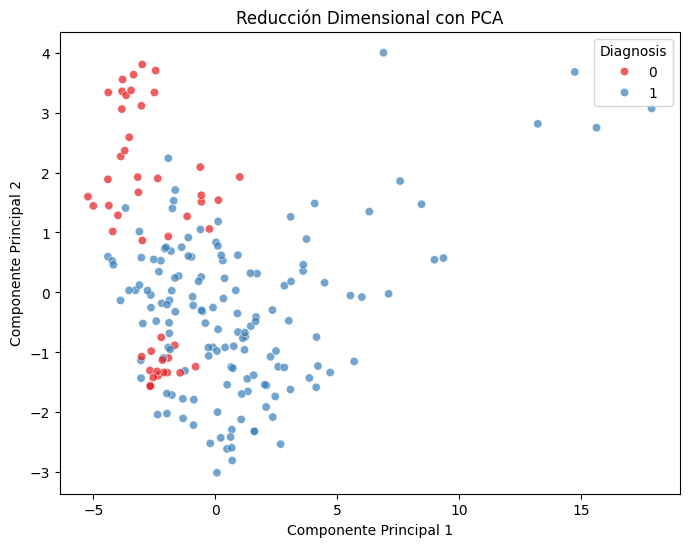

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    palette="Set1",
    alpha=0.7
)

plt.title("Reducción Dimensional con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

las observaciones se distribuyen según las dos componentes principales que concentran la mayor varianza del dataset. Se observa cierta separación entre los pacientes con y sin diagnóstico de Parkinson, aunque existe superposición entre algunos puntos. Esto sugiere que, si bien las componentes principales capturan una parte importante de la información de los datos, la separación entre clases no es completamente clara en este espacio reducido.

**Analizar la varianza explicada por cada componente**

In [52]:
print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)

print("Varianza total explicada:")
print(pca.explained_variance_ratio_.sum())

Varianza explicada por componente:
[0.58900504 0.1129943 ]
Varianza total explicada:
0.7019993419973102


Para fines de visualización, se utilizaron únicamente las dos primeras componentes principales, lo que permite representar los datos en un plano bidimensional. Sin embargo, si el objetivo fuera utilizar PCA como parte de un pipeline de modelado predictivo, sería recomendable conservar un mayor número de componentes, por ejemplo aquellas que permitan explicar alrededor del 90% de la varianza total, lo que en este caso correspondería aproximadamente a 6 componentes principales.

A partir del análisis de la varianza explicada se observa que las dos primeras componentes principales concentran aproximadamente el 70% de la varianza total del dataset, lo que permite capturar una proporción significativa de la información original.

**4.	Aplicación de t-SNE:**

○	Determinar parámetros como perplexity, learning_rate, n_iter.

Con el objetivo de evaluar cómo influye el parámetro perplexity en la representación de los datos, se probaron distintos valores (5, 30, 50 y 100). Este parámetro controla el número aproximado de vecinos que cada punto considera al construir la representación en menor dimensión.

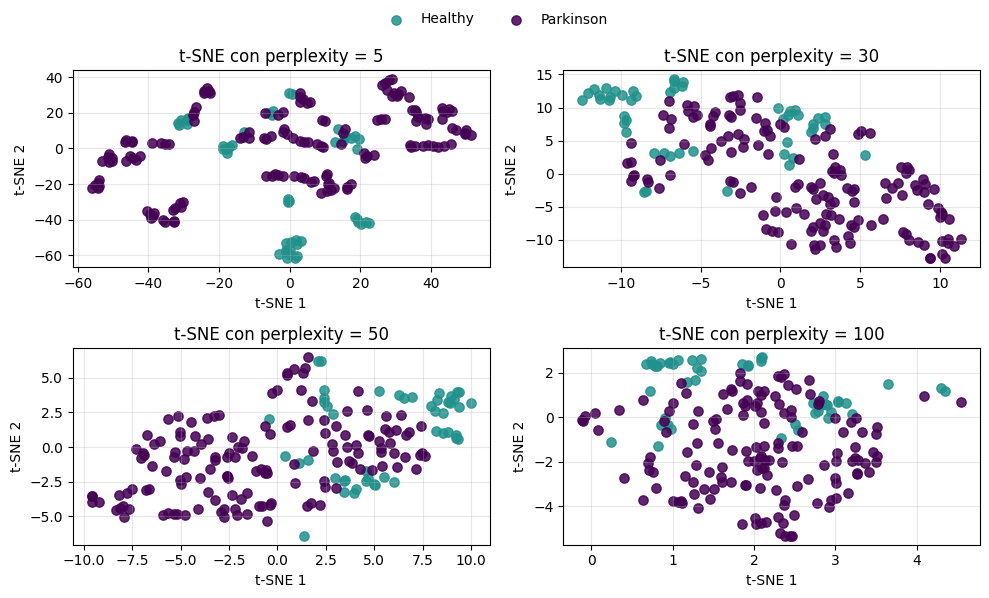

In [53]:
from sklearn.manifold import TSNE

# 1. Cargar dataset
df = pd.read_csv("parkinsons.data")

# 2. Separar variables
X = df.drop(["name","status"], axis=1)
y = df["status"]

# 3. Mapear nombres de clase
class_names = {
    0: "Healthy",
    1: "Parkinson"
}

y_names = y.map(class_names)

# 4. Escalar variables
X_scaled = StandardScaler().fit_transform(X)

# 5. Valores de perplexity a probar
perplexities = [5, 30, 50, 100]

# 6. Colores para cada clase
colors = {
    "Healthy": "#21918c",
    "Parkinson": "#440154"
}

# 7. Crear subplots
fig, axes = plt.subplots(2, 2, figsize=(10,6))
axes = axes.flatten()

for i, perplexity in enumerate(perplexities):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=200,
        max_iter=1000,
        random_state=42
    )

    X_tsne = tsne.fit_transform(X_scaled)

    # Graficar cada clase
    for clase in class_names.values():

        idx = y_names == clase

        axes[i].scatter(
            X_tsne[idx,0],
            X_tsne[idx,1],
            label=clase,
            s=45,
            alpha=0.85,
            color=colors[clase]
        )

    axes[i].set_title(f"t-SNE con perplexity = {perplexity}")
    axes[i].set_xlabel("t-SNE 1")
    axes[i].set_ylabel("t-SNE 2")
    axes[i].grid(True, alpha=0.3)

# Leyenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

A partir de las visualizaciones obtenidas, se observa que valores intermedios de perplexity (como 30 o 50) tienden a generar una separación más clara entre los grupos de pacientes con y sin diagnóstico de Parkinson. En cambio, valores muy bajos o muy altos pueden generar representaciones menos estables o con agrupamientos menos definidos. Por esta razón, se selecciona un valor intermedio como el más adecuado para representar la estructura de los datos en dos dimensiones.

**ADICIONAL: Justificación de elección de perplexity**

Para seleccionar el valor adecuado del hiperparámetro perplexity, se evaluaron distintos valores y se utilizó la métrica trustworthiness, que mide qué tan bien la representación en baja dimensionalidad preserva las relaciones de vecindad del espacio original. 

In [54]:
from sklearn.manifold import TSNE, trustworthiness
import numpy as np

perplexities = [5, 30, 50, 100]

scores = []

for p in perplexities:
    
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate=200,
        max_iter=1000,
        random_state=42
    )
    
    X_tsne = tsne.fit_transform(X_scaled)
    
    score = trustworthiness(X_scaled, X_tsne)
    
    scores.append(score)

for p, s in zip(perplexities, scores):
    print(f"Perplexity {p}: Trustworthiness = {s:.4f}")

Perplexity 5: Trustworthiness = 0.9783
Perplexity 30: Trustworthiness = 0.9769
Perplexity 50: Trustworthiness = 0.9759
Perplexity 100: Trustworthiness = 0.9490


El valor de perplexity seleccionado fue aquel que presentó un buen nivel de trustworthiness, indicando una mejor preservación de la estructura de los datos.

Si bien valores bajos como 5 obtuvieron un valor ligeramente mayor en la métrica de trustworthiness, se observó que valores intermedios como 30 generaban una visualización más clara y estable de los posibles agrupamientos. Por esta razón, se seleccionó perplexity = 30, ya que ofrece un mejor equilibrio entre preservación de la estructura local y claridad en la representación visual de los datos.

**Determinar parámetros como perplexity, learning_rate, n_iter.**

Se seleccionó perplexity = 30 por ser un valor comúnmente utilizado en datasets de tamaño medio y el análisis realizado, learning_rate = 200 para asegurar estabilidad en el entrenamiento y 1000 iteraciones para permitir la convergencia del algoritmo.

**Aplircar t-SNE y visualizar los datos en 2D.**

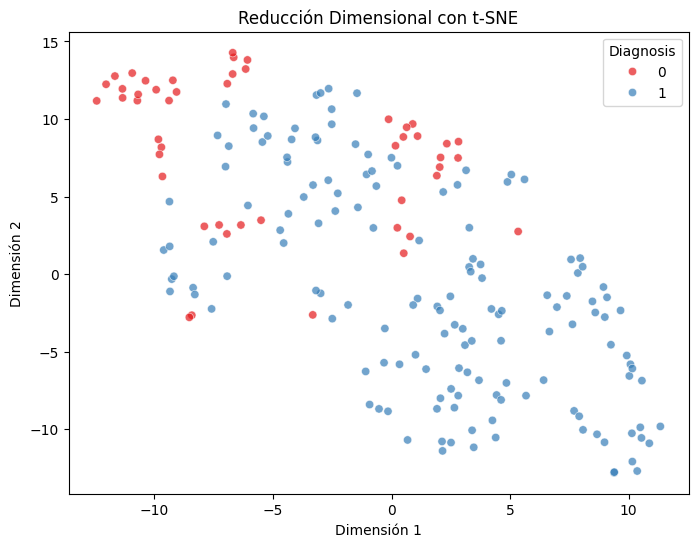

In [55]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)
tsne_df = pd.DataFrame(X_tsne, columns=["Dim1","Dim2"])
tsne_df["Diagnosis"] = y

#Visualización t-SNE con perplexity = 30
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=tsne_df,
    x="Dim1",
    y="Dim2",
    hue="Diagnosis",
    palette="Set1",
    alpha=0.7
)

plt.title("Reducción Dimensional con t-SNE")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")

plt.show()

En la visualización obtenida mediante t-SNE se observa una estructura de agrupamiento más marcada entre las observaciones. Este método preserva mejor las relaciones locales entre los datos, lo que permite identificar de manera más clara posibles clústeres entre pacientes con y sin Parkinson. Sin embargo, aún se observa cierta mezcla entre algunos puntos, lo que refleja la complejidad de distinguir completamente ambas clases únicamente a partir de estas variables biométricas.